# Activity 2 — Exploratory Data Analysis of California Housing

## Learning objectives
By the end of this activity, you should be able to:

1. Load a real-world dataset into a pandas `DataFrame`.
2. Inspect its structure, data types, missing values, and summary statistics.
3. Choose visualisations that answer specific analytical questions.
4. Identify distributions, outliers, relationships, and possible data limitations.
5. Interpret a chart using evidence rather than simply describing its appearance.


### Dataset
We use scikit-learn's **California Housing** dataset. Each row represents a California census block group. The prediction target, `MedHouseVal`, is the median house value expressed in units of **$100,000**. `MedInc` is median income in units of **$10,000**.

## 1. Import the required libraries

We keep the imports together so you can immediately see which packages are used and why.

In [2]:
# Data handling
import pandas as pd

# Visualisation
import matplotlib.pyplot as plt
import seaborn as sns

# Dataset
from sklearn.datasets import fetch_california_housing

# A consistent visual theme makes all charts easier to compare.
sns.set_theme(style="whitegrid", context="notebook")

# Display pandas numbers in a readable form.
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

## 2. Load the dataset

`fetch_california_housing(as_frame=True)` gives us a pandas-friendly version of the dataset. We create one DataFrame containing both the predictors and the target.

In [3]:
housing = fetch_california_housing(as_frame=True)

data = housing.frame.copy()

# Rename the scikit-learn target to the familiar name used in this activity.
data = data.rename(columns={"MedHouseVal": "MedHouseVal"})

print(f"Rows: {data.shape[0]:,}")
print(f"Columns: {data.shape[1]}")
data.head()

Rows: 20,640
Columns: 9


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.33,41.00,6.98,1.02,322.00,2.56,37.88,-122.23,4.53
1,8.30,21.00,6.24,0.97,"2,401.00",2.11,37.86,-122.22,3.58
2,7.26,52.00,8.29,1.07,496.00,2.80,37.85,-122.24,3.52
3,5.64,52.00,5.82,1.07,558.00,2.55,37.85,-122.25,3.41
4,3.85,52.00,6.28,1.08,565.00,2.18,37.85,-122.25,3.42


### Feature guide

| Feature | Meaning |
|---|---|
| `MedInc` | Median income in the block group (× $10,000) |
| `HouseAge` | Median house age |
| `AveRooms` | Average rooms per household |
| `AveBedrms` | Average bedrooms per household |
| `Population` | Block-group population |
| `AveOccup` | Average household occupancy |
| `Latitude`, `Longitude` | Geographic location |
| `MedHouseVal` | Median house value (× $100,000) |

**Question:** Before plotting anything, which variables do you expect to be most closely related to house value? Why?

## 3. First inspection: structure and data quality

A good EDA starts with simple checks. We want to know:
- What does one observation look like?
- Are the columns numeric or categorical?
- Are values missing?
- Are any ranges surprising?

In [4]:
print("DATA TYPES")
print(data.dtypes)

print("\nMISSING VALUES")
print(data.isna().sum())

print("\nDUPLICATED ROWS")
print(data.duplicated().sum())

DATA TYPES
MedInc         float64
HouseAge       float64
AveRooms       float64
AveBedrms      float64
Population     float64
AveOccup       float64
Latitude       float64
Longitude      float64
MedHouseVal    float64
dtype: object

MISSING VALUES
MedInc         0
HouseAge       0
AveRooms       0
AveBedrms      0
Population     0
AveOccup       0
Latitude       0
Longitude      0
MedHouseVal    0
dtype: int64

DUPLICATED ROWS
0


## 4. Summary statistics

`describe()` gives us count, centre, spread, and extreme values. Do not read every number aloud. Instead, look for values that raise useful questions.

In [5]:
summary = data.describe().T
summary[["mean", "std", "min", "25%", "50%", "75%", "max"]]

,mean,std,min,25%,50%,75%,max
MedInc,3.87,1.90,0.50,2.56,3.53,4.74,15.00
HouseAge,28.64,12.59,1.00,18.00,29.00,37.00,52.00
AveRooms,5.43,2.47,0.85,4.44,5.23,6.05,141.91
AveBedrms,1.10,0.47,0.33,1.01,1.05,1.10,34.07
Population,"1,425.48","1,132.46",3.00,787.00,"1,166.00","1,725.00","35,682.00"
AveOccup,3.07,10.39,0.69,2.43,2.82,3.28,"1,243.33"
Latitude,35.63,2.14,32.54,33.93,34.26,37.71,41.95
Longitude,-119.57,2.00,-124.35,-121.80,-118.49,-118.01,-114.31
MedHouseVal,2.07,1.15,0.15,1.20,1.80,2.65,5.00


### How to interpret this table
Focus on three things:

1. **Typical values:** compare the mean and median (`50%`). A large difference can indicate skewness.
2. **Spread:** the standard deviation and interquartile range tell us how variable a feature is.
3. **Extreme values:** very large maxima in variables such as `AveRooms`, `AveOccup`, or `Population` may indicate unusual block groups. They are not automatically errors.

> **Point:** EDA is not about deleting unusual values immediately. First identify them, understand them, and decide whether they are plausible and relevant.

## 5. Distribution of the target variable

### Analytical question
**What do California median house values look like, and is the target evenly distributed?**

A histogram is appropriate because `MedHouseVal` is a continuous numeric variable.

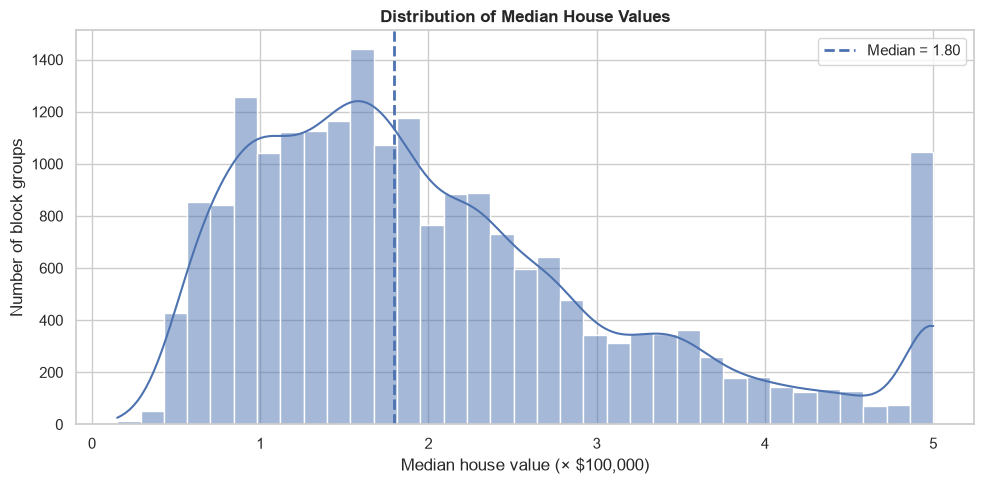

In [6]:
fig, ax = plt.subplots(figsize=(10, 5))

sns.histplot(
    data=data,
    x="MedHouseVal",
    bins=35,
    kde=True,
    ax=ax
)

median_value = data["MedHouseVal"].median()
ax.axvline(median_value, linestyle="--", linewidth=2, label=f"Median = {median_value:.2f}")

ax.set_title("Distribution of Median House Values", fontweight="bold")
ax.set_xlabel("Median house value (× $100,000)")
ax.set_ylabel("Number of block groups")
ax.legend()
plt.tight_layout()
plt.show()

### Interpretation
- The histogram shows the **shape and concentration** of house values rather than only one average.
- Look for skewness, multiple peaks, and unusually high concentrations at the upper end.
- The California Housing target is known to contain an **upper-value ceiling** in the source data. A pile-up near the maximum therefore deserves attention when interpreting models later.
- The dashed median line gives you a useful reference point for what a typical observation looks like.

**Discussion:** Why could a capped target make it harder for a regression model to learn the true prices of the most expensive areas?

## 6. Distributions of the explanatory features

The original notebook displayed every histogram at once. Here we keep that idea, but use a cleaner layout and clearer labels. The purpose is to compare **shape, skewness, and possible extreme values** across features.

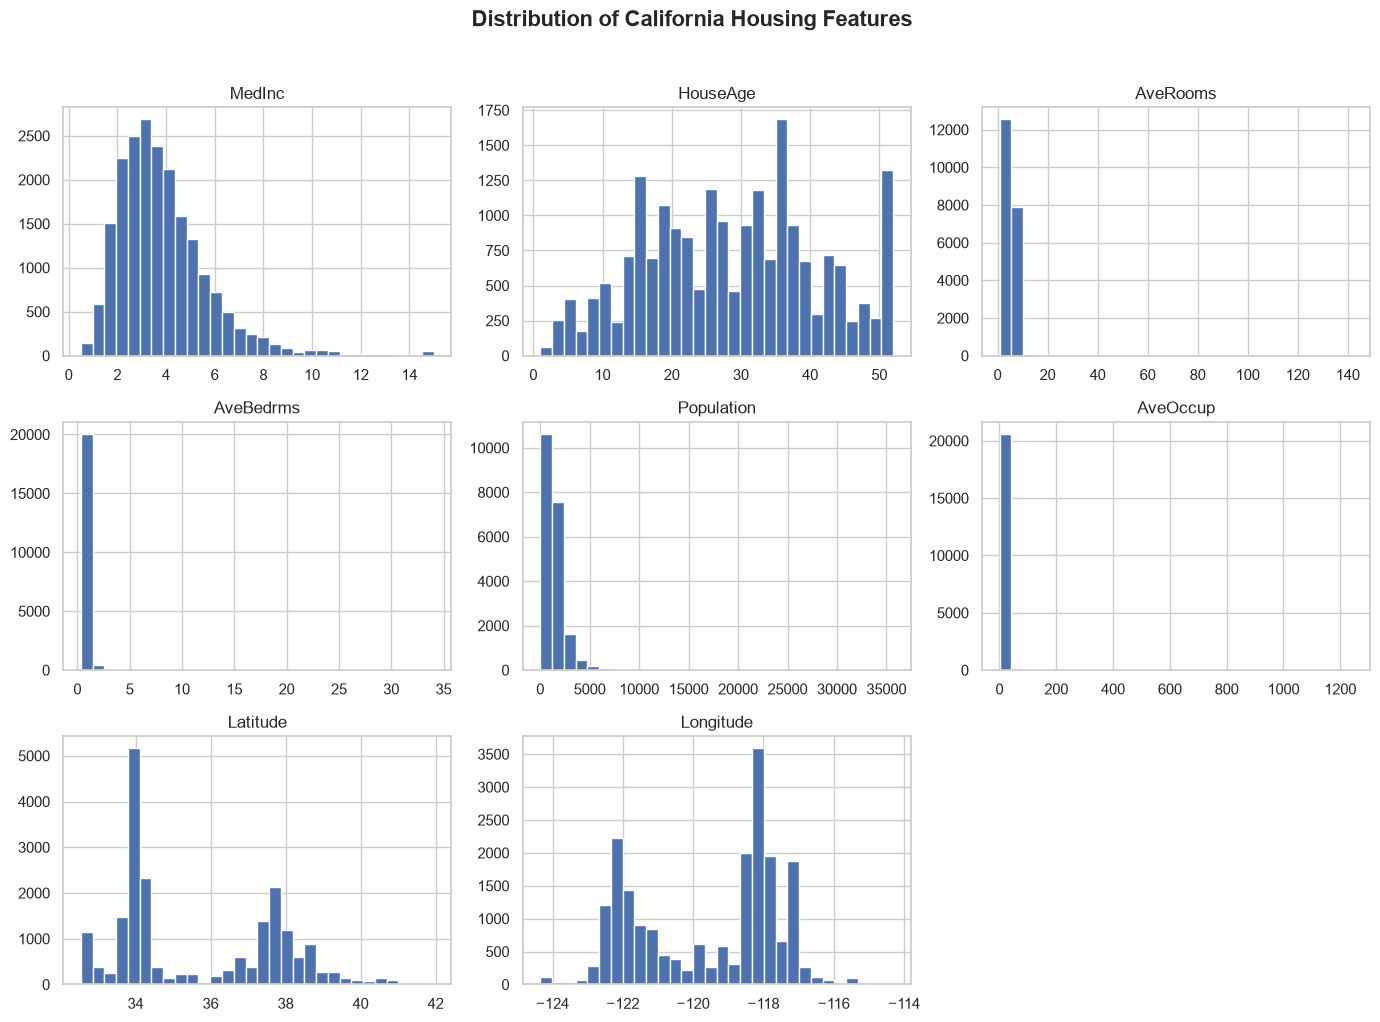

In [7]:
feature_columns = [
    "MedInc", "HouseAge", "AveRooms", "AveBedrms",
    "Population", "AveOccup", "Latitude", "Longitude"
]

axes = data[feature_columns].hist(
    bins=30,
    figsize=(14, 10),
    layout=(3, 3),
    edgecolor="white"
)

plt.suptitle("Distribution of California Housing Features", fontsize=16, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

### Interpretation

- Which variables look approximately symmetric?
- Which are strongly right-skewed?
- Which contain long tails or extreme values?
- Are geographic variables (`Latitude`, `Longitude`) expected to look normally distributed? Why not?

This prepares you for later decisions about transformations, robust statistics, and model selection.

## 7. Which features are most associated with house value?

### Analytical question
**Which numeric variables have the strongest linear relationship with `MedHouseVal`?**

Instead of jumping straight into several scatter plots, we first calculate Pearson correlations. A horizontal bar chart makes the ranking easy to read.

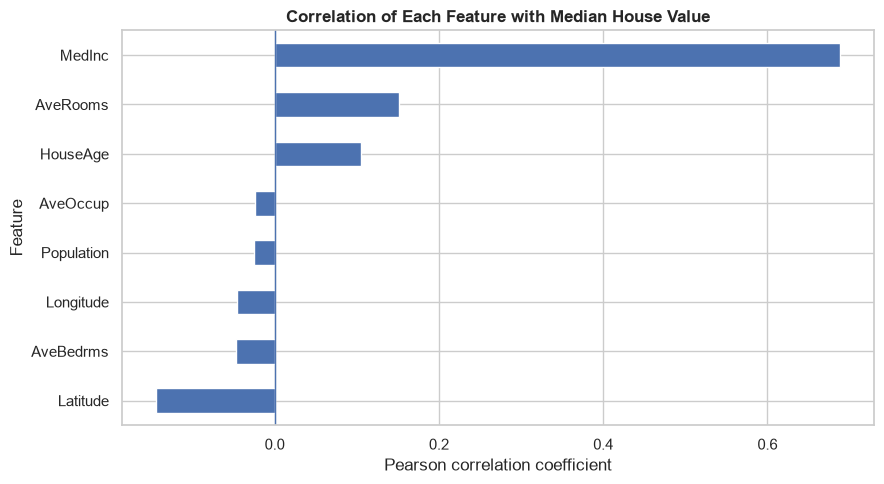

,Correlation with MedHouseVal
MedInc,0.69
AveRooms,0.15
HouseAge,0.11
AveOccup,-0.02
Population,-0.02
Longitude,-0.05
AveBedrms,-0.05
Latitude,-0.14


In [8]:
target_correlations = (
    data.corr(numeric_only=True)["MedHouseVal"]
        .drop("MedHouseVal")
        .sort_values()
)

fig, ax = plt.subplots(figsize=(9, 5))
target_correlations.plot(kind="barh", ax=ax)

ax.axvline(0, linewidth=1)
ax.set_title("Correlation of Each Feature with Median House Value", fontweight="bold")
ax.set_xlabel("Pearson correlation coefficient")
ax.set_ylabel("Feature")
plt.tight_layout()
plt.show()

target_correlations.sort_values(ascending=False).to_frame("Correlation with MedHouseVal")

### Interpretation
- A correlation close to **+1** indicates a strong positive linear relationship; close to **−1** indicates a strong negative linear relationship; close to **0** indicates little *linear* relationship.
- In this dataset, `MedInc` should stand out as the strongest positive linear association with house value.
- Correlation is useful for screening relationships, but **correlation does not imply causation**.
- A small correlation does not prove that a variable is useless: the relationship may be nonlinear or may interact with other variables.

**Question:** If `Latitude` has a negative correlation, does that mean moving north *causes* house prices to fall? What other geographic factors might be involved?

## 8. Median income vs. median house value

### Analytical question
**How does neighbourhood income relate to house value?**

The original scatter plot plotted more than 20,000 points at full opacity, causing overplotting. We use a transparent sample for readability and add a regression line to make the overall pattern easier to see.

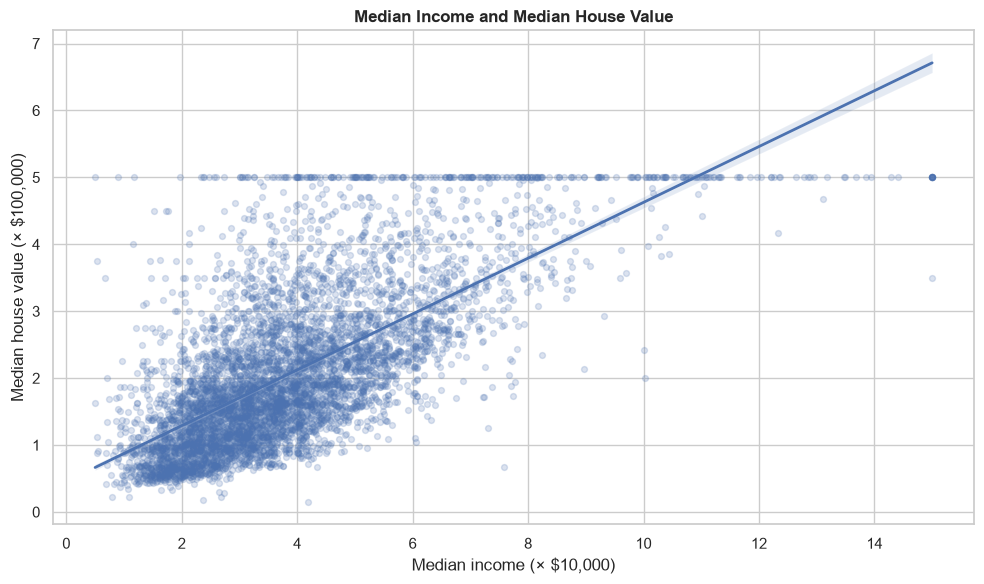

In [9]:
plot_sample = data.sample(n=min(6000, len(data)), random_state=42)

fig, ax = plt.subplots(figsize=(10, 6))

sns.regplot(
    data=plot_sample,
    x="MedInc",
    y="MedHouseVal",
    scatter_kws={"alpha": 0.20, "s": 18},
    line_kws={"linewidth": 2},
    ax=ax
)

ax.set_title("Median Income and Median House Value", fontweight="bold")
ax.set_xlabel("Median income (× $10,000)")
ax.set_ylabel("Median house value (× $100,000)")
plt.tight_layout()
plt.show()

### Interpretation
- The overall upward pattern indicates that **higher-income block groups tend to have higher median house values**.
- The vertical spread shows that income alone does not determine price: areas with similar incomes can still have quite different house values.
- The dense horizontal band near the maximum target value is consistent with the dataset's upper-value ceiling.
- The fitted line summarises the **average linear tendency**; it should not be interpreted as a causal effect.

**Better analytical language:** say *“Median income is positively associated with median house value in this dataset”* rather than *“income causes house prices to increase.”*

## 9. Does having more rooms imply a more expensive area?

### Analytical question
**Is `AveRooms` as informative as income?**

A raw scatter plot can be dominated by extreme observations. We display the central 99% of `AveRooms` for the visual only; the underlying data are not deleted.

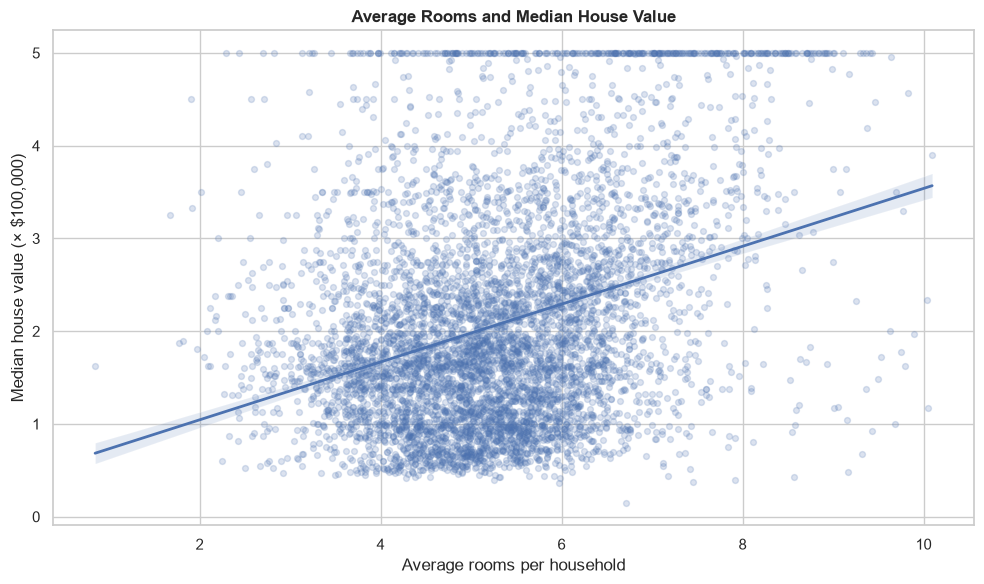

Visualisation limited to AveRooms ≤ 10.36 (99th percentile).


In [10]:
rooms_99 = data["AveRooms"].quantile(0.99)
rooms_for_plot = data.loc[data["AveRooms"] <= rooms_99]
rooms_sample = rooms_for_plot.sample(n=min(6000, len(rooms_for_plot)), random_state=42)

fig, ax = plt.subplots(figsize=(10, 6))

sns.regplot(
    data=rooms_sample,
    x="AveRooms",
    y="MedHouseVal",
    scatter_kws={"alpha": 0.20, "s": 18},
    line_kws={"linewidth": 2},
    ax=ax
)

ax.set_title("Average Rooms and Median House Value", fontweight="bold")
ax.set_xlabel("Average rooms per household")
ax.set_ylabel("Median house value (× $100,000)")
plt.tight_layout()
plt.show()

print(f"Visualisation limited to AveRooms ≤ {rooms_99:.2f} (99th percentile).")

### Interpretation
- Compare the strength and spread of this relationship with the income plot above.
- `AveRooms` may show some positive tendency, but the relationship is much noisier than the income relationship.
- Average rooms is also a **derived block-group measure**, not the room count of one individual property. That distinction matters when explaining the chart.
- Restricting the visual to the 99th percentile prevents a few extreme x-values from compressing the majority of observations. We explicitly report this choice so the chart remains transparent.

**point:** A good chart is not merely attractive; it makes the analytical question easier to answer without hiding important preprocessing decisions.

## 10. House values across income groups

The original notebook used five equal-width income bins. Equal-width bins can contain very different numbers of observations. For comparisons, **quantile groups** are often clearer because each category contains roughly the same number of rows.

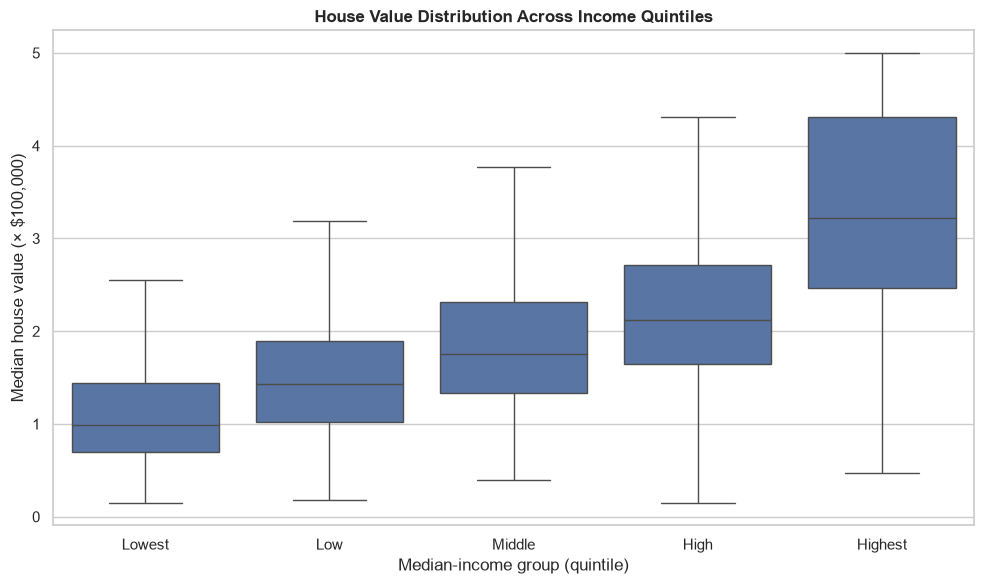

,Number of block groups
IncomeGroup,
Lowest,4130
Low,4131
Middle,4123
High,4128
Highest,4128


In [11]:
income_labels = ["Lowest", "Low", "Middle", "High", "Highest"]

data["IncomeGroup"] = pd.qcut(
    data["MedInc"],
    q=5,
    labels=income_labels,
    duplicates="drop"
)

fig, ax = plt.subplots(figsize=(10, 6))

sns.boxplot(
    data=data,
    x="IncomeGroup",
    y="MedHouseVal",
    order=income_labels,
    showfliers=False,
    ax=ax
)

ax.set_title("House Value Distribution Across Income Quintiles", fontweight="bold")
ax.set_xlabel("Median-income group (quintile)")
ax.set_ylabel("Median house value (× $100,000)")
plt.tight_layout()
plt.show()

# Confirm that the groups contain similar numbers of observations.
data["IncomeGroup"].value_counts(sort=False).to_frame("Number of block groups")

### How to read the box plot
- The **line inside each box** is the median.
- The **box** contains the middle 50% of observations (the interquartile range).
- The **whiskers** show the typical range beyond the box.
- We hide individual outlier markers here because thousands of points would distract from the group comparison; the observations remain in the calculation.

### Interpretation
If the boxes move upward from the lowest to the highest income quintile, that provides an intuitive group-level view of the positive income–house-value association. Also inspect the overlap between boxes: substantial overlap reminds us that income is informative but does not fully explain housing values.

## 11. A more relevant chart: geography of housing value

The dataset contains latitude and longitude, so we can ask a question that the original notebook did not use:

### Analytical question
**Are expensive housing areas geographically clustered?**

A geographic scatter plot is more informative than another generic pairplot because it uses the meaning of the variables.

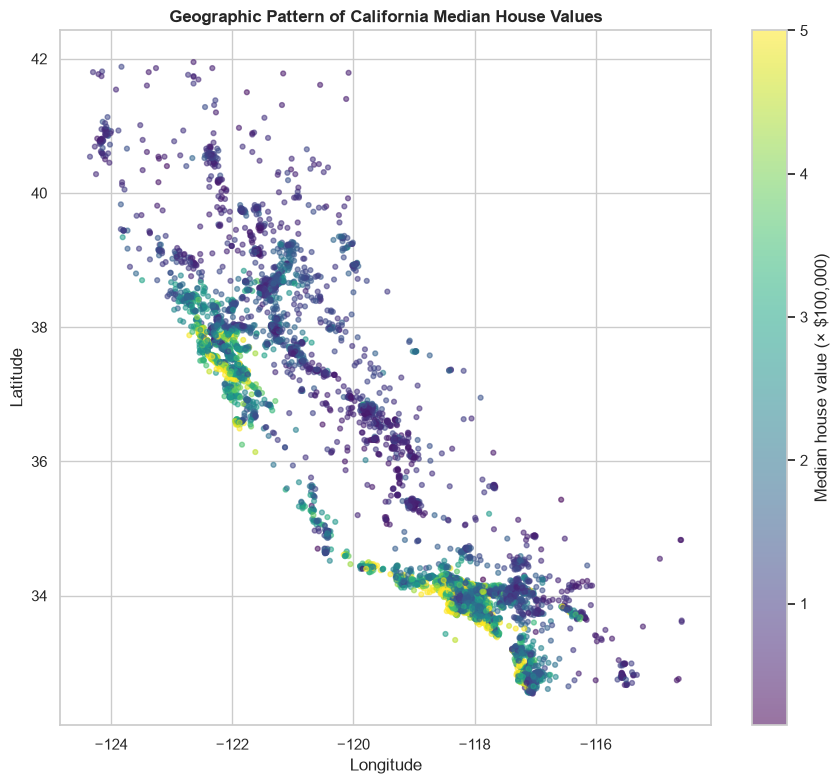

In [12]:
geo_sample = data.sample(n=min(10000, len(data)), random_state=42)

fig, ax = plt.subplots(figsize=(9, 8))

points = ax.scatter(
    geo_sample["Longitude"],
    geo_sample["Latitude"],
    c=geo_sample["MedHouseVal"],
    s=12,
    alpha=0.55,
    cmap="viridis"
)

cbar = fig.colorbar(points, ax=ax)
cbar.set_label("Median house value (× $100,000)")

ax.set_title("Geographic Pattern of California Median House Values", fontweight="bold")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
plt.tight_layout()
plt.show()

### Interpretation
- This chart lets us see **spatial clustering** that a correlation coefficient cannot show.
- Look for concentrations of higher-value observations around major coastal metropolitan regions and compare them with inland areas.
- Geography may therefore contain useful predictive information even if `Latitude` or `Longitude` alone has only a moderate linear correlation with the target.
- This is a good example of why domain-aware visualisation can reveal structure that a generic pairplot misses.

> **Important:** The plot shows association by location. It does not identify which local factors—employment, amenities, land constraints, transport, proximity to the coast, or others—produce the observed values.

## 12. Optional: save the prepared data

Saving should normally come **after** the analytical transformations you actually want to keep. 

In [13]:
data.to_csv("california_housing_eda.csv", index=False)
print("Saved: california_housing_eda.csv")

Saved: california_housing_eda.csv


# Activity summary

In this activity we moved from **description → visualisation → interpretation**:

1. We inspected the dataset before plotting it.
2. We examined the target and feature distributions.
3. We ranked linear associations with house value.
4. We investigated the strongest relationship using a focused scatter plot.
5. We compared income groups using a box plot.
6. We used latitude and longitude to reveal geographic structure.

## Key analytical conclusions
- Median income has a clear positive association with median house value.
- No single feature fully explains housing value; substantial variation remains within similar income levels.
- Extreme values can distort visualisations, so plotting decisions should be explicit and justified.
- Geographic information reveals spatial patterns that cannot be captured by a simple one-variable correlation.
- The target's upper-value ceiling is an important dataset limitation to remember in later modelling.

## Questions
1. Which feature appears most useful for predicting `MedHouseVal`? What evidence supports your answer?
2. Why should we avoid saying that correlation proves causation?
3. Why did we sample points for some scatter plots?
4. Why are quantile-based income groups preferable to arbitrary equal-width bins for this comparison?
5. What new information does the geographic plot provide that the correlation chart does not?
6. What preprocessing or modelling steps would you investigate next?

### Suggested next activity
Use these EDA findings to build a baseline regression model, then evaluate whether adding multiple features improves prediction compared with using `MedInc` alone.